In [2]:
using Pkg 
Pkg.activate("..")
Pkg.instantiate();

  Activating project at `~/PhD/GaussianProcessNode`


In [3]:
using Revise 
using RxInfer
using Random, LinearAlgebra, SpecialFunctions, Plots, StableRNGs, DomainSets,LaTeXStrings   
using StatsFuns
using Zygote, Optim, ForwardDiff, Flux
using JLD
using KernelFunctions, MAT, LoopVectorization
import KernelFunctions: SqExponentialKernel, Matern52Kernel, with_lengthscale, Kernel, kernelmatrix 
import ReactiveMP: approximate_meancov, approximate_kernel_expectation, WishartFast, logdet
import RxInfer: PointMassFormConstraint,call_boundaries, call_starting_point

In [4]:
include("../GPnode/MultiSGPnode.jl")
include("../helper_functions/derivative_helper.jl")
pgfplotsx()

Plots.PGFPlotsXBackend()

In [5]:
function predict_gp(X_test, Xu, Yu, var_Yu,C, kernel)
    Kuu = kron(C,kernelmatrix(kernel,Xu))
    K_test_u =kron(C,kernelmatrix(kernel,X_test,Xu))
    Ktest =kron(C,kernelmatrix(kernel,X_test))

    μ = K_test_u * Yu 
    Σ = Ktest - K_test_u * inv(Kuu + Diagonal(var_Yu)) * K_test_u'
    return μ, Σ
end

function  PredictState(prev_state, qv, qw ,qθ, meta)
    return @call_rule MultiSGP(:out, Marginalisation) (q_in = prev_state, q_v = qv, q_w = qw,q_θ = qθ, meta = meta)
end
function UpdateState(prior_prediction, observation)
    likelihood_update = @call_rule MvNormalMeanCovariance(:μ, Marginalisation) (m_out = PointMass(observation), m_Σ = PointMass(P))
    x = ReactiveMP.prod(GenericProd(), prior_prediction, likelihood_update)
    return x
end

## Prediction
function predict_UT(f, qx,qw, meta)
    qz = ReactiveMP.approximate(meta, f, (qx,))
    prediction_x = @call_rule MvNormalMeanPrecision(:out, Marginalisation) (q_μ = qz, q_Λ = qw)
    return prediction_x
end


predict_UT (generic function with 1 method)

In [6]:
N = 700
max_time = 7
Δt = max_time / (N-1)

function transition_function(x_prev)
    x_1 = x_prev[1] + x_prev[2] * Δt 
    x_2 = x_prev[2] - 9.81 * sin(x_prev[1]) * Δt
    return [x_1, x_2]
end

function generate_data(n,x_init, Q, P;rng = MersenneTwister(124))
    x_prev = x_init  #initial angle and angular velocity
    x = Vector{Vector{Float64}}(undef, n)
    y = Vector{Vector{Float64}}(undef, n)
    for i in 1:n
        x[i] = transition_function(x_prev) + rand(rng, MvNormal(zeros(2),Q))
        y[i] = x[i] + rand(rng, MvNormal(zeros(2),P))
        x_prev = x[i]
    end
    return x, y 
end

generate_data (generic function with 1 method)

In [7]:
qc = 0.01
Q = [qc*Δt^3/3 qc*Δt^2/2;qc*Δt^2/2 qc*Δt]

P = 0.1*diageye(2) 
H = [1,0]
x_init = [1.5, 0.]

x_state, y_observation = generate_data(N,x_init, Q,P);
time_interval = collect(0:Δt:max_time)
;

In [8]:
n_train = 300
true_state_train = x_state[1:n_train]
y_train = y_observation[1:n_train]
true_state_test = x_state[1+n_train:end]
y_test = y_observation[1+n_train:end];

Xu_2_neg1 = reverse(collect(range(-4,0;length=12)));
Xu_2_neg2 = reverse(Xu_2_neg1) .+ 1e-5
Xu_2_pos1 = collect(range(1e-4,4;length=12));
Xu_2_pos2 = reverse(Xu_2_pos1)
Xu_2 = vcat(Xu_2_neg1,Xu_2_neg2,Xu_2_pos1,Xu_2_pos2)

Xu_1 = collect(range(-2,2;length=Int(length(Xu_2)/2)));
Xu_1 = vcat(reverse(Xu_1), Xu_1 .+ 1e-5);

In [9]:
## 2-D data, fully observed
@model function pendulum_GP(y,dim_v,P,θ)
    v ~ MvNormalMeanCovariance(zeros(dim_v), 50*diageye(dim_v))
    W ~ Wishart(1e2,diageye(2))
    x_prev ~ MvNormalMeanCovariance([1.6,0], 0.1*diageye(2))

    for i=1:length(y)
        x[i] ~ MultiSGP(x_prev,v,W,θ)
        y[i] ~ MvNormalMeanCovariance(x[i], P)
        x_prev = x[i]
    end
end

In [10]:
Xu = [[Xu_1[i],Xu_2[i]] for i=1:length(Xu_1)]

kernel_gp(θ) = StatsFuns.softplus(θ[1]) * with_lengthscale(Matern52Kernel(), StatsFuns.softplus.(θ[2:end]))
gp_method = srcubature()
gp_cache = GPCache()

dim_v = size(Xu[1],1) * length(Xu)
M = length(Xu)
D = size(x_state[1],1)
Ψ0 = [1.0;;]
Ψ1_trans = kernelmatrix(kernel_gp([1.,1.]),Xu,[[1., 1.]])
Ψ2 = kernelmatrix(kernel_gp([1.,1.]),Xu,[[1., 1.]]) * kernelmatrix(kernel_gp([1.,1.]),[[1., 1.]],Xu)
;

In [11]:
@meta function gpssm_meta(method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel,cache)
    MultiSGP() -> MultiSGPMeta(method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel,cache)
end

gp_constraint = @constraints begin
    q(x,x_prev,v,W) = q(x)q(x_prev)q(v)q(W)
    q(x) = q(x[begin])..q(x[end])
end

gp_initialization = @initialization begin
    q(v) = MvNormalMeanCovariance(zeros(dim_v),50*diageye(dim_v))
    q(x) = MvNormalMeanCovariance(zeros(2), 50diageye(2))
    q(W) = Wishart(1e2,diageye(2))
end
;

In [12]:
function my_free_energy(θ)
    Kuu = kernelmatrix(kernel_gp(θ),Xu) + 1e-12*I
    Kuu_inverse = cholinv(Kuu)
    infer_result_gp = infer(
        model = pendulum_GP(dim_v = dim_v,P = P, θ = θ,),
        iterations = 10,
        data = (y = y_train,),
        initialization = gp_initialization,
        meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
        constraints = gp_constraint,
        free_energy = true,
    ) 
    
    return infer_result_gp.free_energy[end]
end

function learn_params(θ)
    res = optimize((x) -> my_free_energy(x),θ,NelderMead(),Optim.Options(time_limit = 1000))
    return res.minimizer
end


learn_params (generic function with 1 method)

In [13]:
# θ_init = StatsFuns.invsoftplus.([1.,1.,1.]);
# @time θ_optimal = learn_params(θ_init); #approx 19min

### If you can't wait, load the optimal hyperparameters
θ_optimal = load("../savefiles/params_opt_pendulum_matern52.jld")["params"]

3-element Vector{Float64}:
 -2.093525515111709
  2.500760084098477
  6.755992933735842

In [14]:
println("Optimal hyperparameters: ", StatsFuns.softplus.(θ_optimal))

Optimal hyperparameters: [0.11622790949033025, 2.579592180040736, 6.757156140549498]


In [15]:
save("../savefiles/params_opt_pendulum_matern52.jld","params",θ_optimal)

In [15]:
niter = 30;
Kuu = kernelmatrix(kernel_gp(θ_optimal),Xu) + 1e-12*I
Kuu_inverse = cholinv(Kuu)

infer_result_gp = infer(
    model = pendulum_GP(dim_v = dim_v,P = P, θ = θ_optimal,),
    iterations = niter,
    data = (y = y_train,),
    initialization = gp_initialization,
    meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
    constraints = gp_constraint,
    returnvars = (x = KeepLast(), v = KeepLast(), W = KeepLast(),),
    free_energy = true,
    showprogress = true
) 

Progress: 100%|█████████████████████████████████████████| Time: 0:00:20


Inference results:
  Posteriors       | available for (v, W, x)
  Free Energy:     | Real[2471.66, 1577.27, 700.97, 537.351, 470.069, 433.085, 410.009, 394.823, 384.616, 377.712  …  363.337, 363.273, 363.225, 363.194, 363.164, 363.16, 363.142, 363.14, 363.134, 363.134]


In [16]:
qv_gp = infer_result_gp.posteriors[:v]
qx_gp = infer_result_gp.posteriors[:x];
qw_gp = infer_result_gp.posteriors[:W];

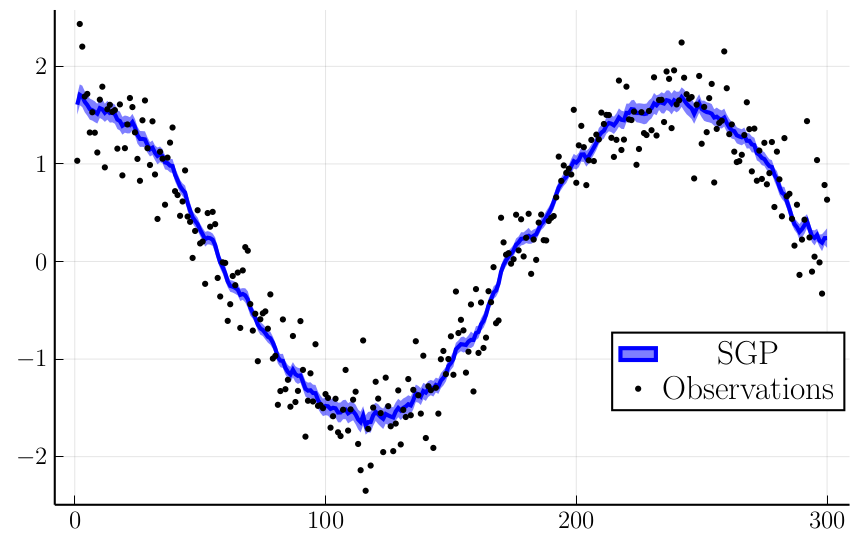

In [17]:
plot(getindex.(mean.(qx_gp),1),ribbon = sqrt.(getindex.(var.(qx_gp),1)),label="SGP",
     lw = 2,
     color=:blue, 
     legend_position=(0.7,0.35),
    fontfamily="monospace",legendfontsize=16, tickfontsize=12,guidefontsize=16)

scatter!(getindex.(y_train,1), markersize=1.5, label="Observations",color=:black)

In [18]:
savefig("../texfiles/pendulum_1st_state_matern52.svg")

"/Users/nguyenhuuminhhoang/PhD/GaussianProcessNode/texfiles/pendulum_1st_state_matern52.svg"

In [20]:
include("../helper_functions/gp_helperfunction.jl")
# smse_UT_1st_state = SMSE(getindex.(true_state_train,1), getindex.(mean.(qx_UT),1))
smse_GPnode_1st_state = SMSE(getindex.(true_state_train,1), getindex.(mean.(qx_gp),1))
println("The smse of SGP node: $smse_GPnode_1st_state")
# println("The smse of UT: $smse_UT_1st_state")

The smse of SGP node: 0.0050943948383138


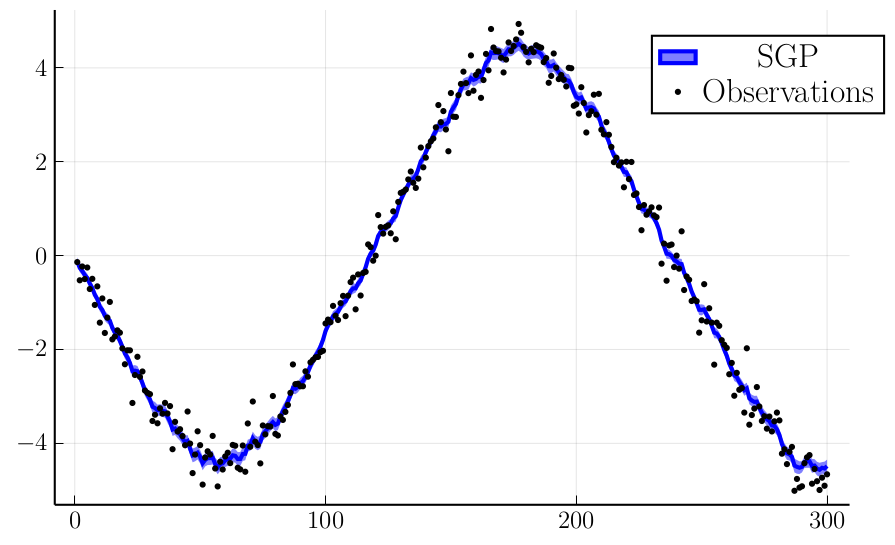

In [19]:
plot(getindex.(mean.(qx_gp),2),ribbon = sqrt.(getindex.(var.(qx_gp),2)),label="SGP", 
        lw = 2, color=:blue,
        fontfamily="monospace",legendfontsize=16,tickfontsize=12,guidefontsize=16,legend_position=(0.75,0.95))

scatter!(getindex.(y_train,2), markersize=1.5, label="Observations", color=:black, alpha=1)

In [20]:
savefig("../texfiles/pendulum_2nd_state_matern52.svg")

"/Users/nguyenhuuminhhoang/PhD/GaussianProcessNode/texfiles/pendulum_2nd_state_matern52.svg"

In [23]:
smse_GPnode_2st_state = SMSE(getindex.(true_state_train,2), getindex.(mean.(qx_gp),2))
println("The smse of SGP node: $smse_GPnode_2st_state")
# println("The smse of UT: $smse_UT_2st_state")

The smse of SGP node: 0.0010994007319357682


In [24]:
prev_state = qx_gp[end]
predicted_state = []
for i=1:length(y_test)
    prediction = PredictState(prev_state,qv_gp,qw_gp,PointMass(θ_optimal), MultiSGPMeta(srcubature(),Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,GPCache()))
    push!(predicted_state,prediction)
    prev_state = UpdateState(prediction, y_test[i])
end


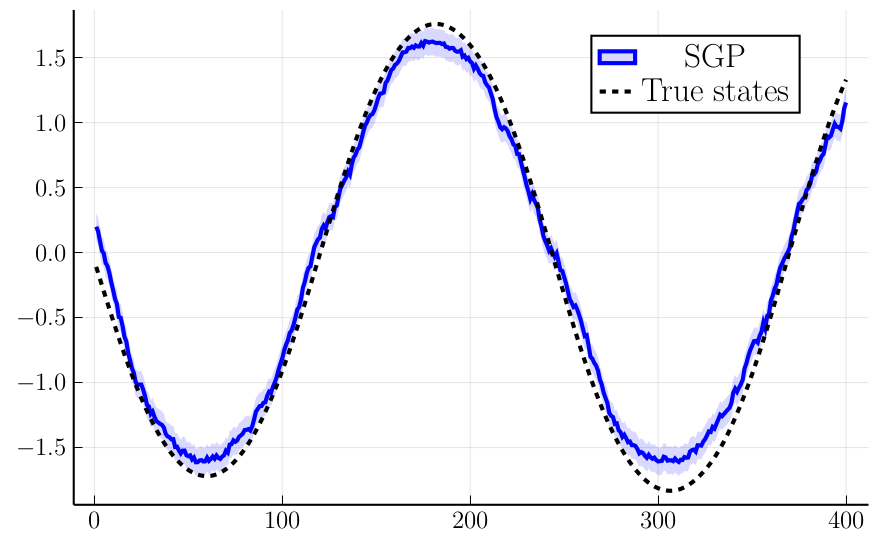

In [25]:
plot(getindex.(mean.(predicted_state),1),ribbon = sqrt.(getindex.(var.(predicted_state),1)) ,
        label="SGP",lw=2, color=:blue,legend_position=(0.65,0.95),
        fontfamily="monospace",legendfontsize=16, fillalpha=0.15,tickfontsize=12,guidefontsize=16)

plot!(getindex.(true_state_test,1),label="True states", ls=:dash,lw=2, color=:black)


In [26]:
savefig("../texfiles/pendulum_1stepprediction_matern52.svg")

"/Users/nguyenhuuminhhoang/PhD/GaussianProcessNode/texfiles/pendulum_1stepprediction_matern52.svg"

In [ ]:
# function my_free_energy(θ)
#     Kuu = kernelmatrix(kernel_gp(θ),Xu) + 1e-12*I
#     Kuu_inverse = cholinv(Kuu)
#     infer_result_gp = infer(
#         model = pendulum_GP(dim_v = dim_v,P = P, θ = θ,),
#         iterations = 10,
#         data = (y = y_train,),
#         initialization = gp_initialization,
#         meta = gpssm_meta(gp_method,Xu,Ψ0,Ψ1_trans,Ψ2,Kuu_inverse,kernel_gp,gp_cache),
#         constraints = gp_constraint,
#         returnvars = (x_prev = KeepLast(),x = KeepLast(), v = KeepLast(), W = KeepLast()),
#         free_energy = true,
#     ) 
    
#     return infer_result_gp.free_energy[end], infer_result_gp.posteriors[:x_prev], 
#             infer_result_gp.posteriors[:x], infer_result_gp.posteriors[:v], infer_result_gp.posteriors[:W]
# end

# function PerformInference(θ; epochs)
#     FE_value = []
#     θ_optimal = θ
#     grad = similar(θ)
#     optimizer = Flux.AdaMax()
#     @inbounds for epoch=1:epochs
#             #step 1: Perform inference for v, w 
#             fe, qx_prev, qx, qv, qW = my_free_energy(θ_optimal)
#             #step 2: optimize the hyperparameters 
#             gp_qy = mean.(qx) #for output of gp node
#             gp_qx = vcat([qx_prev,qx[1:end-1]]...) #for input of gp node
#             μ_v, Σ_v = mean_cov(qv)
#             Rv = Σ_v + μ_v * μ_v' 
#             W_bar = mean(qW)
#             sumRv_Wbar = sum(create_blockmatrix(Rv,D,M) .* W_bar);
#             for k=1:100
#                 grad_llh_multi!(grad,θ_optimal; y_data=gp_qy,
#                                                 qx = gp_qx,
#                                                 sumRv_Wbar = sumRv_Wbar,
#                                                 v = μ_v,
#                                                 W = W_bar,
#                                                 tr_W = tr(W_bar),
#                                                 kernel=kernel_gp,
#                                                 Xu=Xu,
#                                                 method=gp_method)
#                 Flux.Optimise.update!(optimizer,θ_optimal,grad)
#             end
#             append!(FE_value,fe)
#     end
#     return FE_value, θ_optimal
# end